In [11]:
import numpy as np
import matplotlib.pyplot as plt
import random
from torch.utils.data import DataLoader, TensorDataset, Dataset
from math import floor
from tqdm import tqdm

import torch.nn            as nn
import torch.nn.functional as F
import torch

random.seed(42)

In [12]:
sample_uniform = lambda : random.uniform(-2*np.pi, 2*np.pi)

In [13]:
class CustomSinDataset(Dataset):
    def __init__(self, phase_shift: float | None = None, period_shift: float | None = None, n_samples: int | None = 100):
        """
        https://www.mathsisfun.com/algebra/amplitude-period-frequency-phase-shift.html
        https://www.youtube.com/watch?v=wT45v8sIMDM&t=3s
        """
        self.phase_shift  = phase_shift  if not phase_shift  else sample_uniform()
        self.period_shift = period_shift if not period_shift else sample_uniform()
        self.n = n_samples

        self.c1 = self.__generate_curve__()

        self.X_list = [sample_uniform() for _ in range(self.n)]
        self.Y_list = [self.c1(x) for x in self.X_list]

        self.X = torch.from_numpy(np.array(self.X_list)).type(torch.float32).unsqueeze(dim = 1)
        self.Y = torch.from_numpy(np.array(self.Y_list)).type(torch.float32).unsqueeze(dim = 1)

    def __len__(self):
        return len(self.X)
    
    def __generate_curve__(self):
        shift  = random.uniform(-2*np.pi, 2*np.pi)
        period = random.randint(1,6)
        return lambda x: np.sin(period * (x + shift) )

    def __getitem__(self, idx):
        return self.X[idx],self.Y[idx]

    def plot(self, model = None):
        line_space = np.linspace(start=-2*np.pi,stop= 2*np.pi,num = 100)
        plt.plot(line_space,[self.c1(x) for x in line_space])
        plt.scatter(self.X_list,self.Y_list, c = 'r')
        plt.grid(visible=True)

        if model:
            model.eval()
            line_space_tensor = torch.from_numpy(np.array(line_space)).type(torch.float32).unsqueeze(dim = 1)
            plt.scatter(line_space, [model(x).item() for x in line_space_tensor], c = 'b')
            plt.grid(visible=True)
        plt.show()

def train_model(model,device, optimizer ,data_loader, loss_module, num_epochs=100):
    model.train()
    train_losses  = []
    for epoch in tqdm(range(num_epochs)):
        for data_inputs, data_labels in data_loader:
            # Put training data into GPU
            data_inputs = data_inputs.to(device)
            data_labels = data_labels.to(device)

            preds = model(data_inputs).to(device)
            loss  = loss_module(preds, data_labels)
            train_losses.append(loss.item())

            # Zero the gradients
            optimizer.zero_grad()
            loss     .backward()
            optimizer.step()

    return train_losses

In [14]:
model = nn.Sequential(
    nn.Linear(1, 40),
    nn.ReLU(),
    nn.Linear(40, 40),
    nn.ReLU(),
    nn.Linear(40, 1),
)

loss_module = torch.nn.MSELoss()
optimizer   = torch.optim.Adam(model.parameters(), lr=0.01, betas = (0.9,0.99)) #(0.1,0.3)

In [15]:
tasks         = [CustomSinDataset(n_samples=3) for _ in range(1_000)]
tasks_loaders = [DataLoader(t,batch_size=len(t),shuffle=False) for t in tasks]

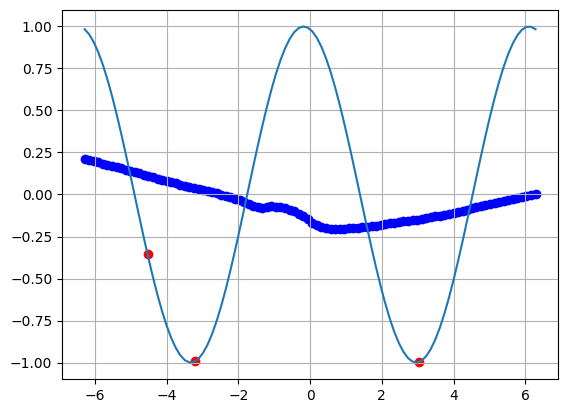

In [16]:
tasks[0].plot(model = model)

In [17]:
model.train()
train_losses  = []
for rounds in tqdm(range(100)):
    for task in tasks_loaders:
        loss = None
        for data_inputs, data_labels in task:
            # Put training data into GPU
            preds = model(data_inputs)
            l  = loss_module(preds, data_labels)
            train_losses.append(l.item())
        if loss:
            loss += l 
        else:
            loss = l
    # Zero the gradients
    optimizer.zero_grad()
    loss     .backward()
    optimizer.step()

100%|██████████| 100/100 [00:11<00:00,  8.71it/s]


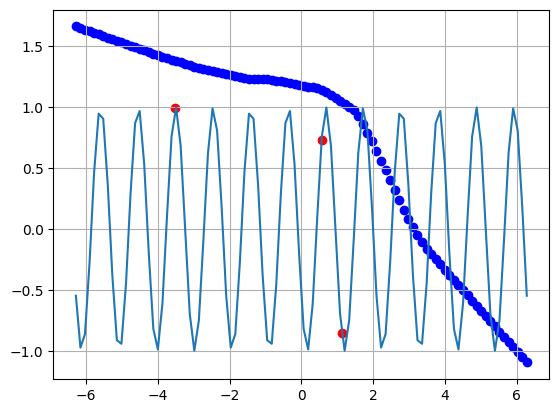

In [18]:
tasks[3].plot(model = model)

In [19]:
D1 = CustomSinDataset(n_samples=50)

D1_train = DataLoader(D1, batch_size = len(D1), shuffle = False)

100%|██████████| 10/10 [00:00<00:00, 870.62it/s]


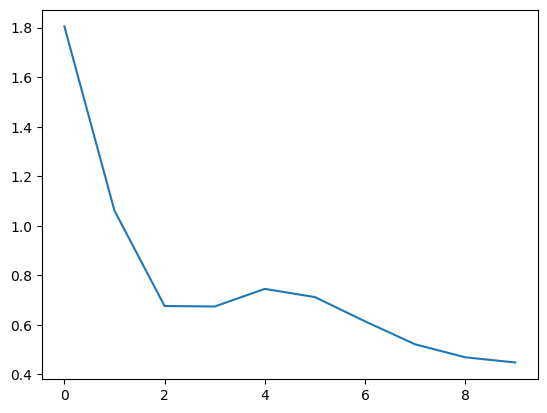

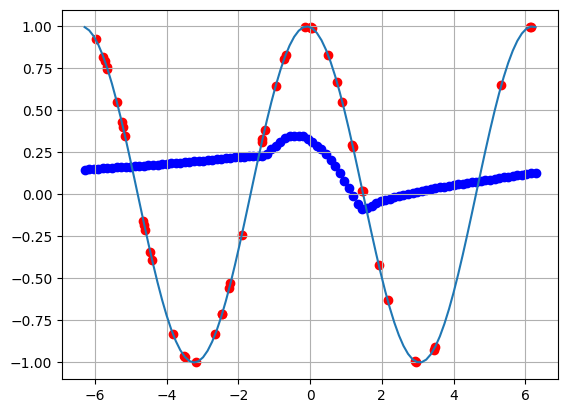

In [20]:
history = train_model(
    model       = model,
    device      = torch.device("cpu"),
    optimizer   = optimizer,
    data_loader = D1_train,
    loss_module = loss_module,
    num_epochs  = 10
)
plt.plot(history)
plt.show()
D1.plot(model = model)